<a href="https://colab.research.google.com/github/Amulyanrao7777/ML/blob/main/lab4_linear_regression_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Analyze house prices using the dataset from `/content/Real estate.csv`. The task involves loading and preprocessing the data, performing exploratory data analysis, training and evaluating both Linear Regression and Naive Bayes models, and comparing their performance. The Linear Regression model will predict the exact house price, while the Naive Bayes model will classify house prices into 'Low', 'Medium', or 'High' categories.

## Load Dataset

### Subtask:
Load the dataset from the specified local path `/content/Real estate.csv` into a pandas DataFrame and perform an initial inspection to understand its structure, columns, and data types.


**Reasoning**:
Load the dataset, display its head, info, and shape for initial inspection as requested.



In [4]:
import pandas as pd

# Define the file path
file_path = '/content/Real estate.csv'

# Load the dataset into a pandas DataFrame
df = pd.read_csv(file_path)

# Display the first 5 rows of the DataFrame
print("First 5 rows of the DataFrame:")
display(df.head())

# Print a concise summary of the DataFrame
print("\nDataFrame Information:")
df.info()

# Print the dimensions of the DataFrame
print("\nDataFrame Shape (rows, columns):")
print(df.shape)

First 5 rows of the DataFrame:


,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1



DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB

DataFrame Shape (rows, columns):
(414, 8)


## Data Preprocessing

### Subtask:
Clean the data by handling missing values, encoding categorical features (if any), and transforming features as necessary for both regression and classification tasks. Ensure data types are appropriate.


**Reasoning**:
The first instruction is to inspect the DataFrame for any missing values. This will identify if any data cleaning related to missing values is required.



In [5]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
No                                        0
X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64


**Reasoning**:
The previous step confirmed no missing values. The next step is to rename columns for better readability and consistency as instructed, which is part of data preprocessing.



In [6]:
new_column_names = {
    'X1 transaction date': 'transaction_date',
    'X2 house age': 'house_age',
    'X3 distance to the nearest MRT station': 'distance_to_mrt',
    'X4 number of convenience stores': 'num_convenience_stores',
    'X5 latitude': 'latitude',
    'X6 longitude': 'longitude',
    'Y house price of unit area': 'house_price_per_unit_area'
}
df = df.rename(columns=new_column_names)
print("DataFrame columns renamed successfully.")
print("New column names:")
print(df.columns.tolist())

DataFrame columns renamed successfully.
New column names:
['No', 'transaction_date', 'house_age', 'distance_to_mrt', 'num_convenience_stores', 'latitude', 'longitude', 'house_price_per_unit_area']


## Exploratory Data Analysis (EDA)

### Subtask:
Perform EDA to understand the distribution of house prices, relationships between features and target variables, and identify potential outliers. Visualize key relationships.


**Reasoning**:
The first step in EDA is to understand the target variable's basic statistical properties. This involves calculating descriptive statistics for 'house_price_per_unit_area' using the `.describe()` method.



In [7]:
print("Descriptive statistics for 'house_price_per_unit_area':")
display(df['house_price_per_unit_area'].describe())

Descriptive statistics for 'house_price_per_unit_area':


,house_price_per_unit_area
count,414.000000
mean,37.980193
std,13.606488
min,7.600000
25%,27.700000
50%,38.450000
75%,46.600000
max,117.500000


**Reasoning**:
The next step in EDA is to visualize the distribution of the target variable 'house_price_per_unit_area' using a histogram, as per the instructions. This will help in understanding its spread and skewness.



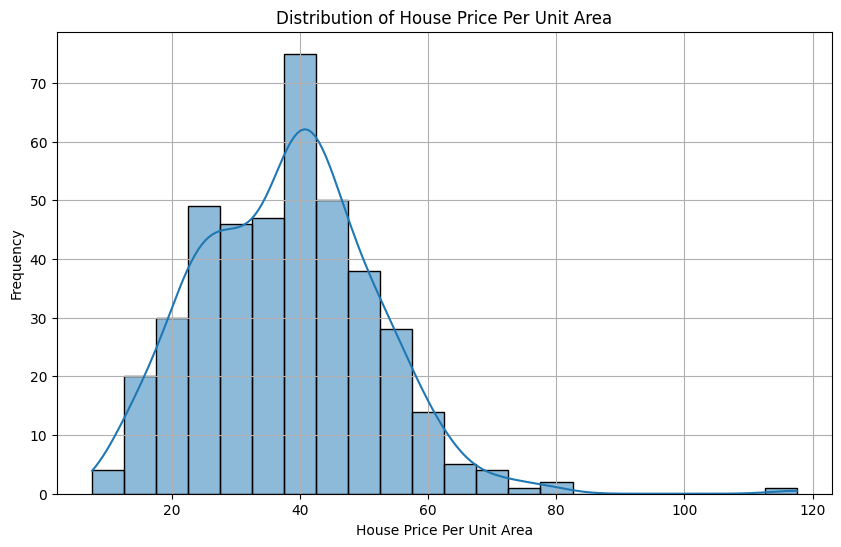

Histogram of 'house_price_per_unit_area' displayed.


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['house_price_per_unit_area'], kde=True)
plt.title('Distribution of House Price Per Unit Area')
plt.xlabel('House Price Per Unit Area')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()
print("Histogram of 'house_price_per_unit_area' displayed.")

**Reasoning**:
Following the instructions for EDA, the next step is to generate a correlation matrix for all numerical features to identify linear relationships. This is crucial for understanding feature interactions.



In [9]:
numeric_df = df.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()
print("Correlation Matrix:")
display(correlation_matrix.round(2))

Correlation Matrix:


,No,transaction_date,house_age,distance_to_mrt,num_convenience_stores,latitude,longitude,house_price_per_unit_area
No,1.00,-0.05,-0.03,-0.01,-0.01,-0.01,-0.01,-0.03
transaction_date,-0.05,1.00,0.02,0.06,0.01,0.04,-0.04,0.09
house_age,-0.03,0.02,1.00,0.03,0.05,0.05,-0.05,-0.21
distance_to_mrt,-0.01,0.06,0.03,1.00,-0.60,-0.59,-0.81,-0.67
num_convenience_stores,-0.01,0.01,0.05,-0.60,1.00,0.44,0.45,0.57
latitude,-0.01,0.04,0.05,-0.59,0.44,1.00,0.41,0.55
longitude,-0.01,-0.04,-0.05,-0.81,0.45,0.41,1.00,0.52
house_price_per_unit_area,-0.03,0.09,-0.21,-0.67,0.57,0.55,0.52,1.00


**Reasoning**:
The next step in EDA, as per the instructions, is to visualize the correlation matrix using a heatmap. This provides a clear visual representation of the relationships between numerical features.



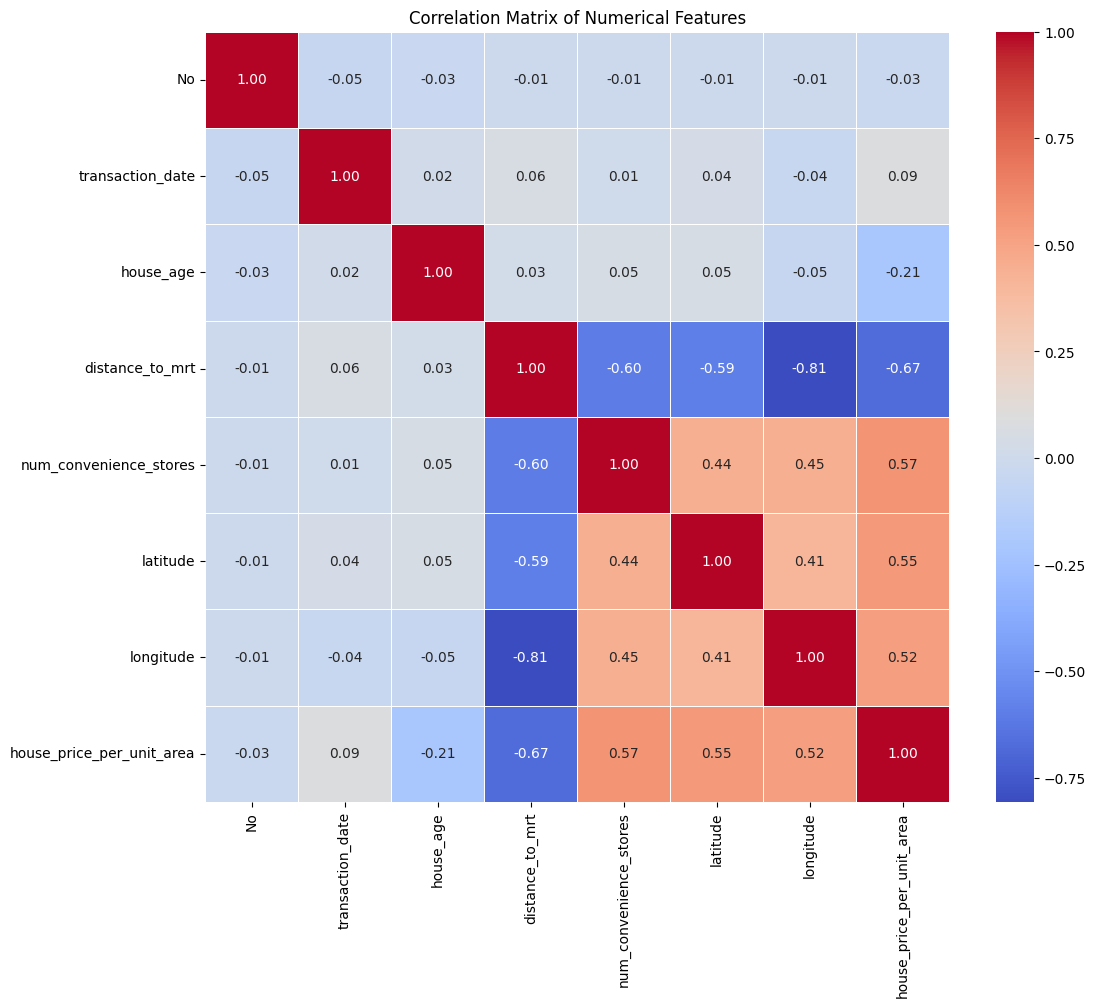

Heatmap of the correlation matrix displayed.


In [10]:
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()
print("Heatmap of the correlation matrix displayed.")

**Reasoning**:
The next step in EDA, as per the instructions, is to create scatter plots to visualize the relationship between the target variable 'house_price_per_unit_area' and key features ('house_age', 'distance_to_mrt', 'num_convenience_stores'). This helps in identifying trends and patterns.



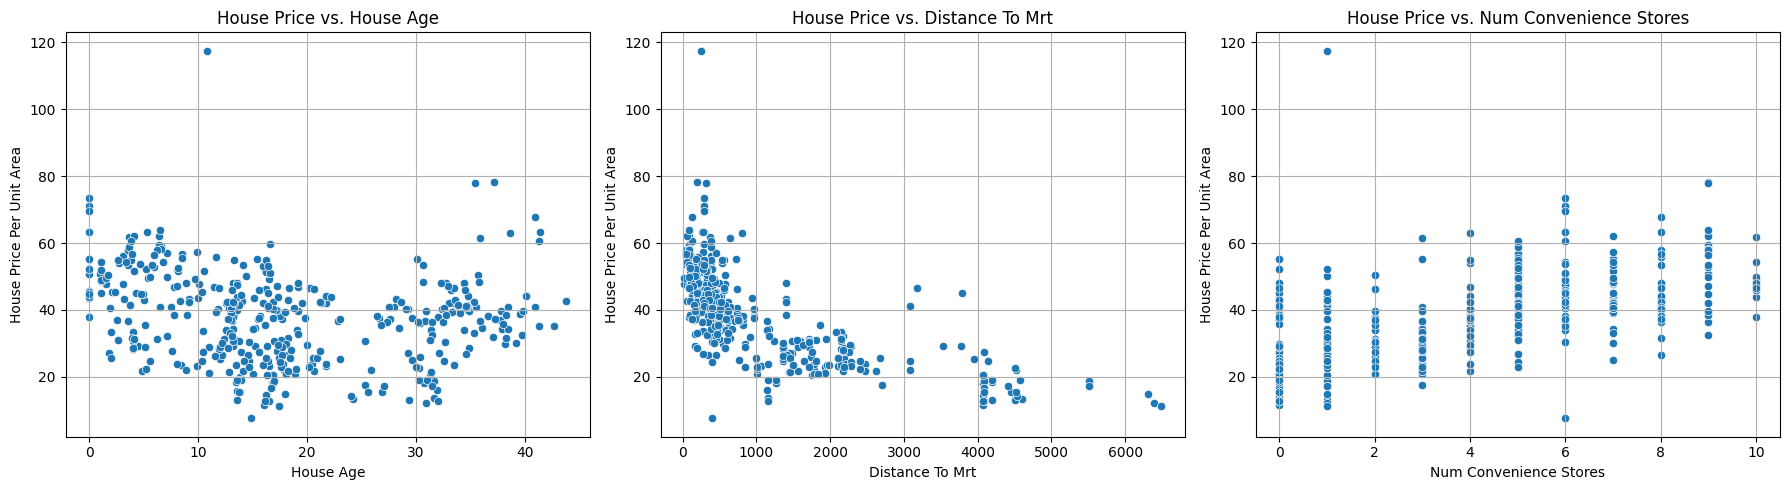

Scatter plots of house price vs. key features displayed.


In [11]:
key_features = ['house_age', 'distance_to_mrt', 'num_convenience_stores']

plt.figure(figsize=(18, 5))

for i, feature in enumerate(key_features):
    plt.subplot(1, len(key_features), i + 1)
    sns.scatterplot(x=df[feature], y=df['house_price_per_unit_area'])
    plt.title(f'House Price vs. {feature.replace("_", " ").title()}')
    plt.xlabel(feature.replace("_", " ").title())
    plt.ylabel('House Price Per Unit Area')
    plt.grid(True)

plt.tight_layout()
plt.show()
print("Scatter plots of house price vs. key features displayed.")

## Data Splitting for Regression

### Subtask:
Split the preprocessed data into training and testing sets for the Linear Regression task, with the exact house price as the target variable.


**Reasoning**:
The first instruction is to define the features (X) and the target variable (y) for the regression task, using 'house_price_per_unit_area' as the target and all other relevant numerical columns (excluding 'No') as features.



In [12]:
X = df.drop(columns=['No', 'house_price_per_unit_area'])
y = df['house_price_per_unit_area']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("Features selected:", X.columns.tolist())

Features (X) shape: (414, 6)
Target (y) shape: (414,)
Features selected: ['transaction_date', 'house_age', 'distance_to_mrt', 'num_convenience_stores', 'latitude', 'longitude']


**Reasoning**:
The next step in the subtask is to import the `train_test_split` function and then split the data into training and testing sets, as per the instructions.



In [13]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("Data split into training and testing sets successfully.")

X_train shape: (331, 6)
X_test shape: (83, 6)
y_train shape: (331,)
y_test shape: (83,)
Data split into training and testing sets successfully.


## Linear Regression Model Training and Evaluation

### Subtask:
Train a Linear Regression model for house price prediction and evaluate its performance using appropriate regression metrics (e.g., R-squared, MSE, RMSE). Visualize actual vs. predicted prices.


**Reasoning**:
The first instruction is to import the necessary libraries for Linear Regression and evaluation metrics, instantiate and train the model, make predictions, and calculate the evaluation metrics (MSE, RMSE, R2 score).



In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Instantiate the Linear Regression model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = linear_model.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2) Score: {r2:.2f}")

Mean Squared Error (MSE): 53.51
Root Mean Squared Error (RMSE): 7.31
R-squared (R2) Score: 0.68


**Reasoning**:
The next instruction is to create a scatter plot to visualize the actual prices (`y_test`) against the predicted prices (`y_pred`) and add a line representing perfect predictions. This will visually demonstrate the model's performance.



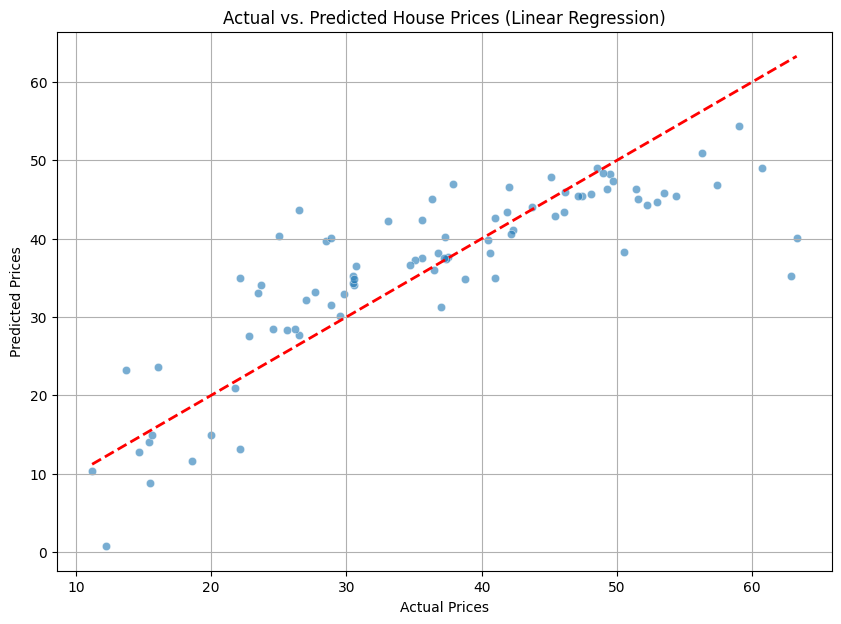

Scatter plot of actual vs. predicted house prices displayed.


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs. Predicted House Prices (Linear Regression)')
plt.grid(True)
plt.show()

print("Scatter plot of actual vs. predicted house prices displayed.")

## Classification Target Preparation

### Subtask:
Create a new categorical target variable (Low, Medium, High price categories) from the house prices for the Naive Bayes classification task. Define the thresholds for these categories.


**Reasoning**:
The first instruction is to define thresholds for 'Low', 'Medium', and 'High' house price categories based on the distribution of the 'house_price_per_unit_area' column, using quantiles.



In [16]:
# Define thresholds using quantiles for 'Low', 'Medium', and 'High' categories
low_threshold = df['house_price_per_unit_area'].quantile(0.33)
medium_threshold = df['house_price_per_unit_area'].quantile(0.66)

print(f"Low price threshold (33rd percentile): {low_threshold:.2f}")
print(f"Medium price threshold (66th percentile): {medium_threshold:.2f}")

# Create the 'price_category' column using pd.cut()
bins = [-float('inf'), low_threshold, medium_threshold, float('inf')]
labels = ['Low', 'Medium', 'High']
df['price_category'] = pd.cut(df['house_price_per_unit_area'], bins=bins, labels=labels, include_lowest=True)

print("\nValue counts for the new 'price_category' column:")
display(df['price_category'].value_counts())

Low price threshold (33rd percentile): 31.16
Medium price threshold (66th percentile): 42.76

Value counts for the new 'price_category' column:


,count
price_category,
High,141
Low,137
Medium,136


## Data Splitting for Classification

### Subtask:
Split the data (with the new categorical target) into training and testing sets for the Naive Bayes classification task.


**Reasoning**:
The first instruction is to define the features (X_clf) and the target variable (y_clf) for the classification task, using the new 'price_category' as the target and excluding 'No' and the original price column.



In [17]:
X_clf = df.drop(columns=['No', 'house_price_per_unit_area', 'price_category'])
y_clf = df['price_category']

print("Features for classification (X_clf) shape:", X_clf.shape)
print("Target for classification (y_clf) shape:", y_clf.shape)
print("Features selected for classification:", X_clf.columns.tolist())

Features for classification (X_clf) shape: (414, 6)
Target for classification (y_clf) shape: (414,)
Features selected for classification: ['transaction_date', 'house_age', 'distance_to_mrt', 'num_convenience_stores', 'latitude', 'longitude']


**Reasoning**:
The next step in the subtask is to split the `X_clf` and `y_clf` into training and testing sets using `train_test_split` as per the instructions, and then print the shapes of the resulting sets.



In [18]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets for classification
X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

print("X_clf_train shape:", X_clf_train.shape)
print("X_clf_test shape:", X_clf_test.shape)
print("y_clf_train shape:", y_clf_train.shape)
print("y_clf_test shape:", y_clf_test.shape)
print("Classification data split into training and testing sets successfully.")

X_clf_train shape: (331, 6)
X_clf_test shape: (83, 6)
y_clf_train shape: (331,)
y_clf_test shape: (83,)
Classification data split into training and testing sets successfully.


## Naive Bayes Model Training and Evaluation

### Subtask:
Train a Naive Bayes model for house price classification and evaluate its performance using appropriate classification metrics (e.g., accuracy, precision, recall, F1-score). Display a confusion matrix.


**Reasoning**:
The first instruction is to import the necessary libraries for the Gaussian Naive Bayes model and its evaluation metrics, then instantiate and train the model, make predictions, calculate and print the classification metrics (accuracy, precision, recall, F1-score), and finally generate and visualize the confusion matrix as part of the model evaluation for the classification subtask.



Naive Bayes Model Performance:
Accuracy: 0.80
Precision (weighted): 0.81
Recall (weighted): 0.80
F1-Score (weighted): 0.80


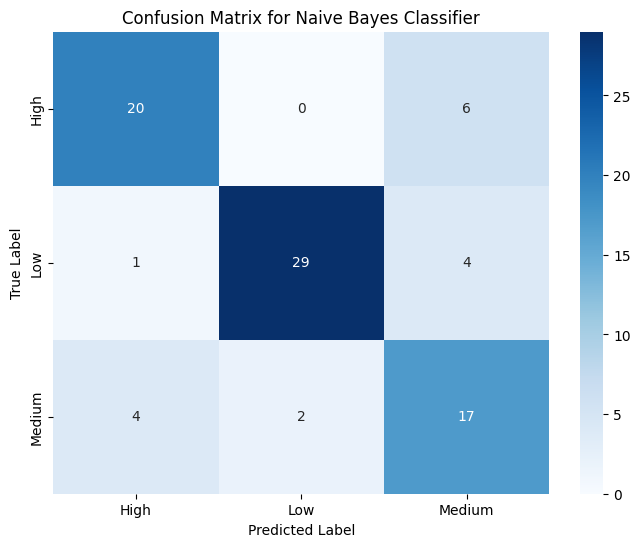

Confusion matrix displayed for Naive Bayes Classifier.


In [19]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Instantiate the Gaussian Naive Bayes model
naive_bayes_model = GaussianNB()

# Train the model
naive_bayes_model.fit(X_clf_train, y_clf_train)

# Make predictions on the test set
y_clf_pred = naive_bayes_model.predict(X_clf_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_clf_test, y_clf_pred)
precision = precision_score(y_clf_test, y_clf_pred, average='weighted', zero_division=0)
recall = recall_score(y_clf_test, y_clf_pred, average='weighted', zero_division=0)
f1 = f1_score(y_clf_test, y_clf_pred, average='weighted', zero_division=0)

print(f"Naive Bayes Model Performance:")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision (weighted): {precision:.2f}")
print(f"Recall (weighted): {recall:.2f}")
print(f"F1-Score (weighted): {f1:.2f}")

# Generate Confusion Matrix
cm = confusion_matrix(y_clf_test, y_clf_pred)

# Visualize the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=naive_bayes_model.classes_, yticklabels=naive_bayes_model.classes_)
plt.title('Confusion Matrix for Naive Bayes Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()
print("Confusion matrix displayed for Naive Bayes Classifier.")

## Model Comparison and Conclusion

### Subtask:
Compare the performance of Linear Regression and Naive Bayes models based on their respective evaluation metrics and summarize findings to identify the most suitable technique for house price prediction and classification.


## Summary:

### Data Analysis Key Findings

*   The dataset was successfully loaded with 414 entries and 8 columns, with no missing values identified across any features.
*   Descriptive statistics for 'house\_price\_per\_unit\_area' show a mean of approximately 37.98, a standard deviation of 13.61, and values ranging from 7.6 to 117.5.
*   Exploratory Data Analysis revealed strong correlations with 'house\_price\_per\_unit\_area':
    *   A significant negative correlation with 'distance\_to\_mrt' (-0.67), indicating prices decrease as distance to the MRT increases.
    *   Positive correlations with 'num\_convenience\_stores' (0.57), 'latitude' (0.55), and 'longitude' (0.52).
    *   A slight negative correlation with 'house\_age' (-0.21).
*   **Linear Regression Model Performance:**
    *   The model achieved a Mean Squared Error (MSE) of 53.51 and a Root Mean Squared Error (RMSE) of 7.31.
    *   The R-squared (R2) score was 0.68, indicating that the model explains 68% of the variance in house prices.
*   **Naive Bayes Model Performance:**
    *   House prices were categorized into 'Low', 'Medium', and 'High' using quantiles (Low < 31.16, Medium 31.16-42.76, High > 42.76), resulting in a balanced distribution across categories.
    *   The Naive Bayes classifier achieved an Accuracy of 0.80, Precision (weighted) of 0.81, Recall (weighted) of 0.80, and F1-Score (weighted) of 0.80.

### Insights or Next Steps

*   The Linear Regression model provides a reasonable predictive capability for continuous house prices, explaining a significant portion of the variance. Further efforts could explore feature engineering or more complex regression models to improve the R-squared score.
*   The Naive Bayes model demonstrates strong performance in classifying house prices into 'Low', 'Medium', or 'High' categories, which could be valuable for high-level market segmentation or quick assessment. Depending on the business need, this model is robust for classification tasks.
